# Import Libraries

In [1]:
import sys
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
from sklearn.feature_selection import VarianceThreshold
from IPython.display import display, Markdown

# Loading Dataset

In [ ]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import RAW_DATA_DIR

import pandas as pd

# Load the CSV
file_path = RAW_DATA_DIR / "raw_diabetes_data.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# Univariate Analysis

In [6]:
#summary of BMI
print(df['BMI'].describe())

count    70692.000000
mean        29.856985
std          7.113954
min         12.000000
25%         25.000000
50%         29.000000
75%         33.000000
max         98.000000
Name: BMI, dtype: float64


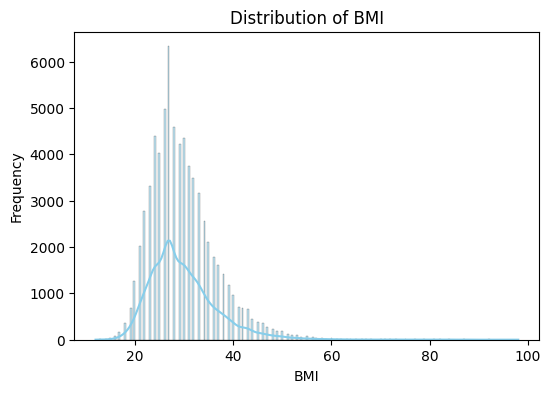

In [7]:
plt.figure(figsize=(6, 4))
sns.histplot(df['BMI'], kde=True, color='skyblue')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

### Binary Variables

In [8]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col != 'BMI']

# Collect all value counts into a dict
count_dict = {}
for col in binary_cols:
    count_dict[col] = df[col].value_counts()

# Combine into a single DataFrame
grid_df = pd.concat(count_dict, axis=1).fillna(0).astype(int)

display(Markdown("### Binary Columns Value Counts"))
display(grid_df)


### Binary Columns Value Counts

,Diabetes_binary,HighBP,HighChol,CholCheck,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex
0.0,35346,30860,33529,1749,37094,66297,60243,20993,27443,14932,67672,3184,64053,52826,38386
1.0,35346,39832,37163,68943,33598,4395,10449,49699,43249,55760,3020,67508,6639,17866,32306


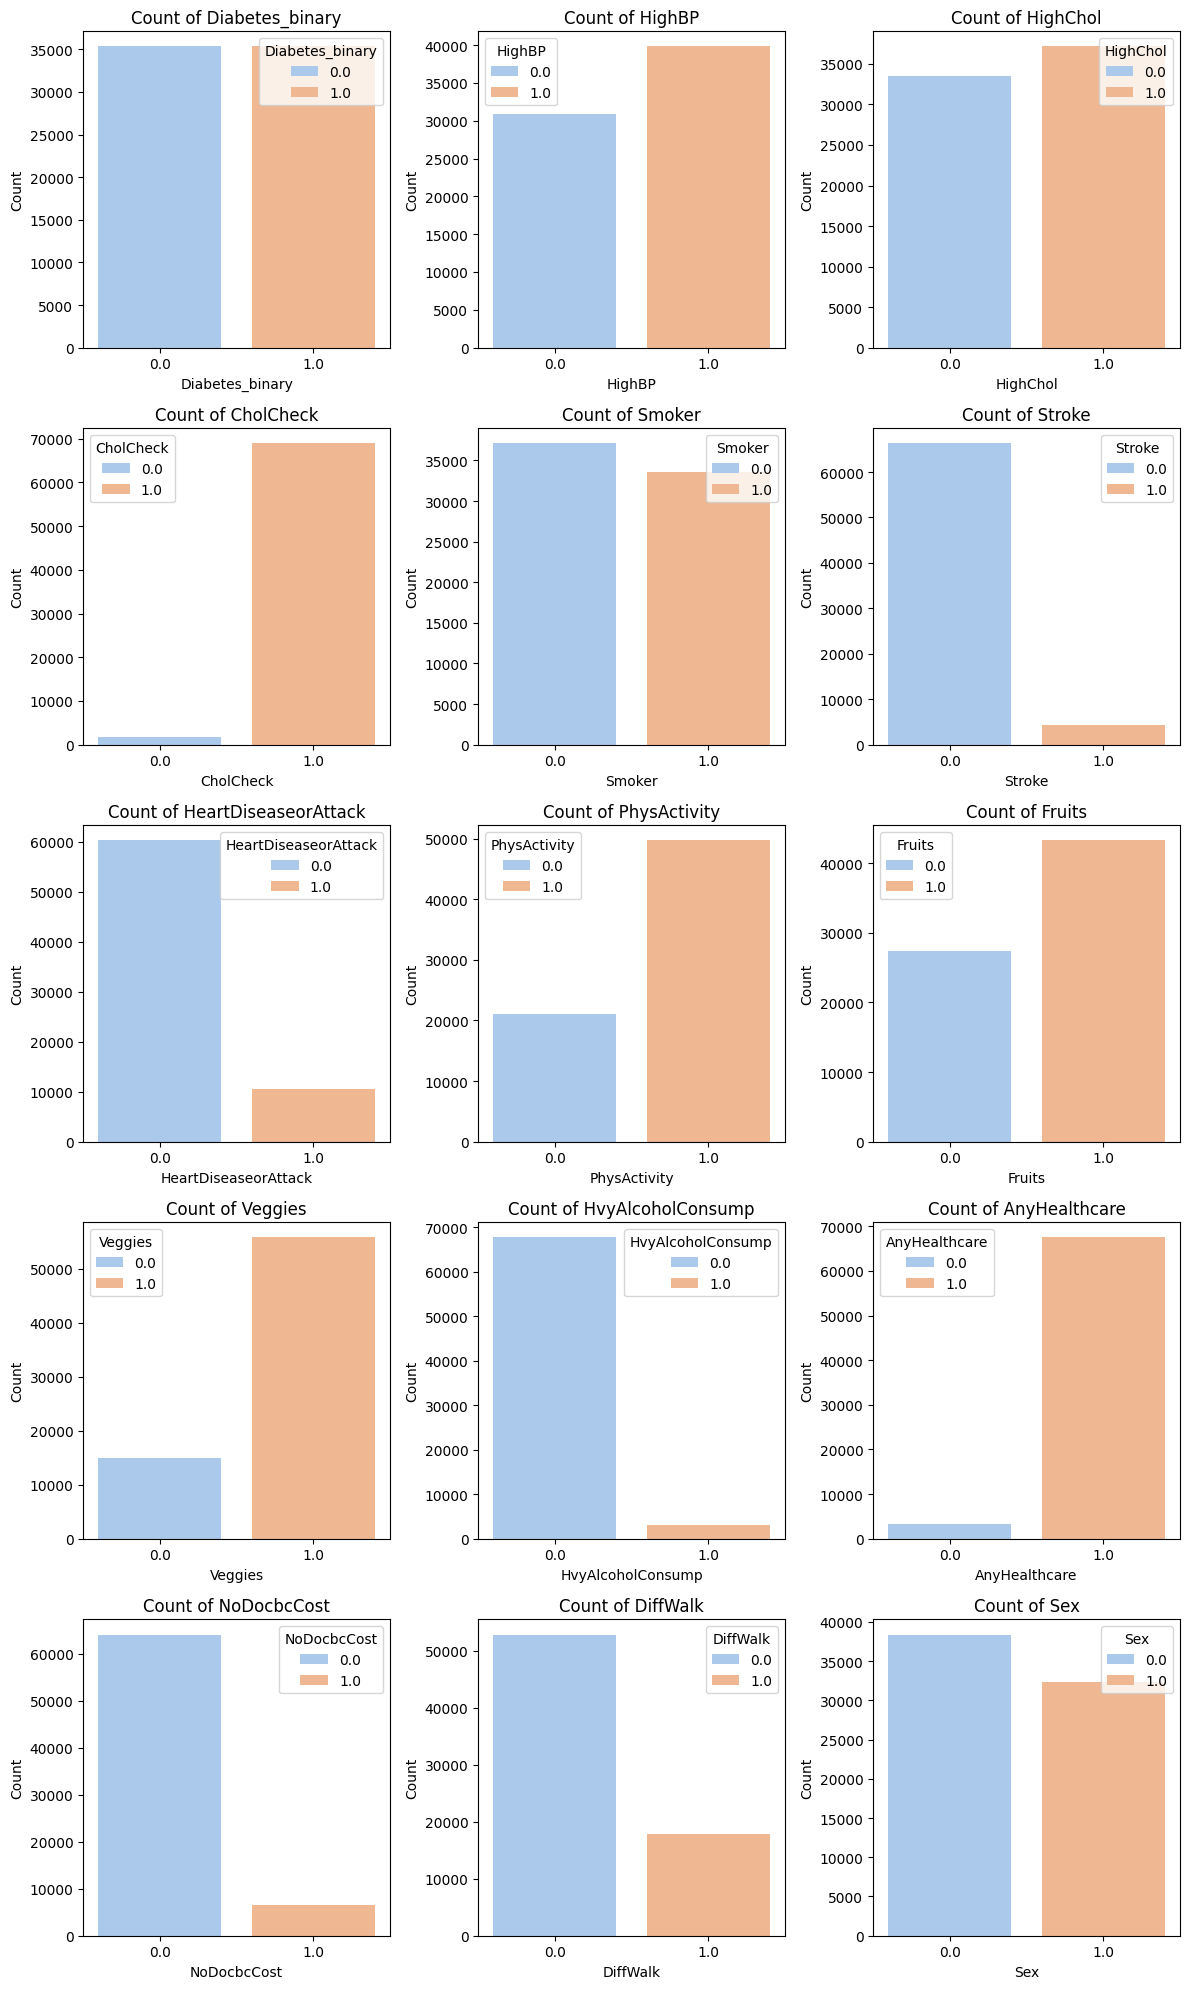

In [9]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2 and col != 'BMI']

n_cols = 3  # Number of columns in the grid
n_rows = (len(binary_cols) + n_cols - 1) // n_cols  # Ceiling division for rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(binary_cols):
    sns.countplot(x=col, data=df, ax=axes[idx], palette="pastel", hue=col)
    axes[idx].set_title(f'Count of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')

# Turn off any unused axes
for i in range(len(binary_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

###  Discrete Variables

For Features which are not binary in nature are encoded in various Buckets.
The Buckets and its extent are given below.

**GenHlth** - General Health

|Bucket|Meaning|
|------|-----------|
|1|Excellent|
|2|Very Good|
|3|Good|
|4|Fair|
|5|Poor|

---

**Age**

|Bucket|Meaning|
|------|-------|
|1|18-24|
|2|25-29|
|3|30-34|
|4|35-39|
|5|40-44|
|6|45-49|
|7|50-54|
|8|55-59|
|9|60-64|
|10|65-69|
|11|70-74|
|12|75-79|
|13|80 or above|

---

**Education**

|Bucket|Meaning|
|------|-------|
|1|Never Attended school or only Kindergarten|
|2|Grades 1 through 8 (elementary)|
|3|Grades 9 through 11 (Some high school)|
|4|Grade 12 or GED (High school graduate)|
|5|College 1 year to 3 years (Some college or technical school)|
|6|College 4 years or more (College graduate)|

---

**Income**

|Bucket|Meaning|
|------|-------|
|1|less than $10,000|
|2|$10,000-$15,000|
|3|$15,000 to $20,000|
|4|$20,000 to $25,000|
|5|$25,000 to $35,000|
|6|$35,000 to $50,000|
|7|$50,000 to $75,000|
|8|more than $75,000|

---

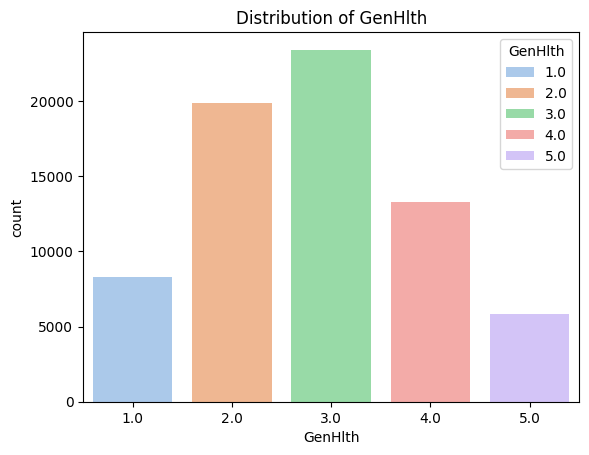

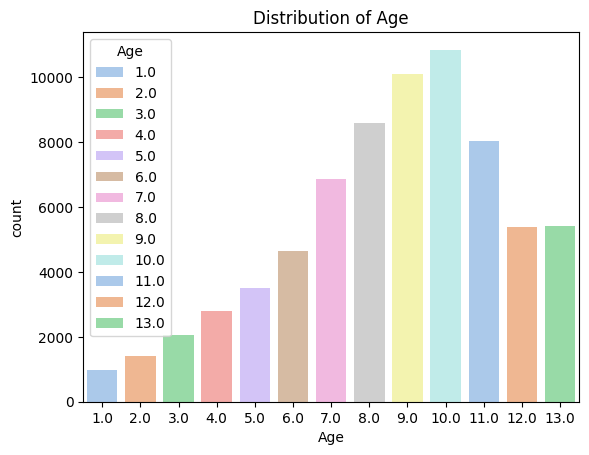

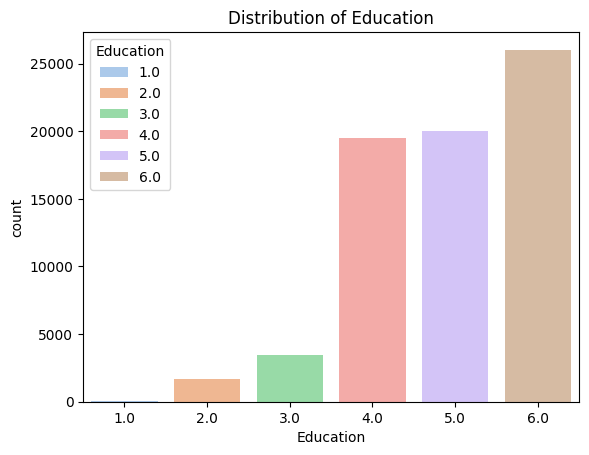

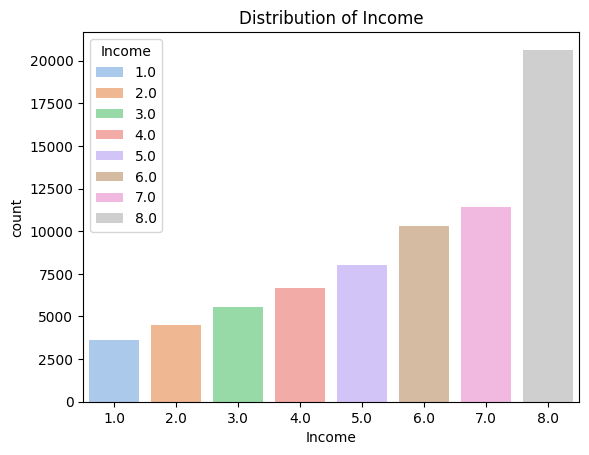

In [10]:
discrete_cols = [col for col in df.columns if 2 < df[col].nunique() < 15 and df[col].dtype in ['int64', 'float64']]
for col in discrete_cols:
    sns.countplot(x=col, data=df, palette='pastel', hue=col)
    plt.title(f'Distribution of {col}')
    plt.show()


### Finding low variance columns

In [11]:
num_cols = df.select_dtypes(include=np.number).columns
selector = VarianceThreshold(threshold=0.01)
selector.fit(df[num_cols])
low_variance_cols = [col for col, var in zip(num_cols, selector.variances_) if var < 0.01]
print("Low Variance Columns:", low_variance_cols)

Low Variance Columns: []
